In [4]:
import tensorflow as tf
import numpy as np
import os
import re
import matplotlib.pyplot as plt

# Function to read and parse the tensor data from a text file
def parse_tensor_from_file(file_path, shape):
    with open(file_path, 'r') as file:
        # Read the content of the file
        tensor_str = file.read()

    components = re.findall(r"([+-]?\d+\.?\d*[eE]?[+-]?\d*(?:\s*[+-]?\d*\.?\d*[eE]?[+-]?\d*j)?)", tensor_str)
    # Convert the components into a numpy array of complex numbers
    complex_numbers = [complex(c.replace(' ','')) for c in components]

    # Convert the list to a NumPy array and reshape it
    numpy_tensor = np.array(complex_numbers, dtype=np.complex128)

    if (shape == 3):
        numpy_tensor = numpy_tensor.reshape(round(numpy_tensor.size ** (1/shape)),round(numpy_tensor.size ** (1/shape)),round(numpy_tensor.size ** (1/shape)))
    if (shape == 2):
        size = numpy_tensor.size
        new_shape = (round(size ** (1/shape)), round(size ** (1/shape))) if shape == 2 else (size,)
        numpy_tensor = numpy_tensor.reshape(new_shape)
    # Convert NumPy array to TensorFlow tensor
    tf_tensor = tf.convert_to_tensor(numpy_tensor)

    return tf_tensor

def retrieve_dict(base_dir, filename, reverse = False):
    # Dictionary to hold costs organized by prefix (i)
    fidelity_dict = {}
    
    # Iterate through each subfolder in the base directory
    folder_names = os.listdir(base_dir)
    
    # Iterate through each subfolder in the base directory
    for folder_name in folder_names:
        folder_path = os.path.join(base_dir, folder_name)
        if os.path.isdir(folder_path):
            # Extract the prefix for identifying the 'i' value
            prefix = (folder_name.split('_')[1]).split('.')[0] + '_' + folder_name.split('_')[2]
            # Path to the cost.txt file
            cost_file_path = os.path.join(folder_path, filename)
            
            # Read the cost value from the cost.txt file
            if os.path.exists(cost_file_path):
                    # Extract the complex number part using regular expression
                    tensor = parse_tensor_from_file(cost_file_path, 1)
                    # Convert the extracted string to a complex number
                    for t in tensor.numpy():
                         # Get the real part and convert to float
                         float_value = t.real
                         if (reverse == True):
                             float_value = 1 - t.real
                         # if (float_value < 10e-4): continue
                         if prefix not in fidelity_dict:
                              fidelity_dict[prefix] = []
                         fidelity_dict[prefix].append(abs(float_value))
    
    return fidelity_dict

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


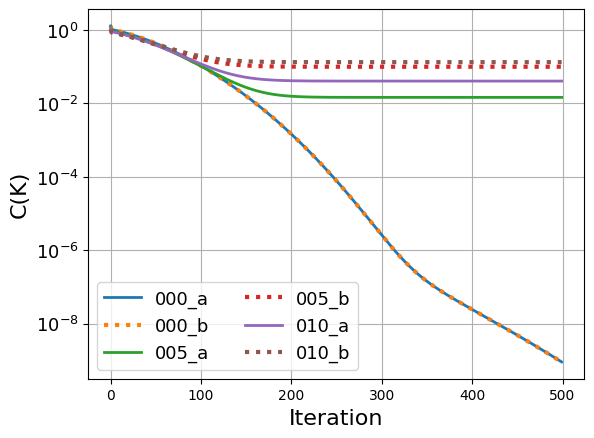

In [5]:
def plot_dict(fidelity_dict, xlabel, ylabel, file_name):
    # Plotting
    for i, (key, values) in enumerate(fidelity_dict.items()):
        x = np.arange(len(values)) 
        if "b" in key.lower():
            # Plot as lines for other keys
            plt.plot(
                x, values, label=key, linestyle='dotted', alpha=1, linewidth=3
            )
        else:
            # Plot as dots for keys containing 'unitary'
            plt.plot(
                x, values, label=key, linestyle='solid', alpha=1, linewidth=2
            )
    plt.xlabel(xlabel, fontsize=16)
    plt.ylabel(ylabel, fontsize=16)
    plt.yscale('log')  # Set y-axis to logarithmic scale
    #x_ticks = np.arange(0, max_val, step=step)
    #plt.xticks(ticks=x_ticks, fontsize=13)
    plt.yticks(fontsize=13)
    plt.grid(True)
    plt.legend(fontsize=13, ncol=2)
    plt.savefig(f'../../docs/new_fig/{file_name}.png', format='png',  bbox_inches='tight')
    plt.savefig(f'../../docs/new_fig/{file_name}.eps', format='eps',  bbox_inches='tight')
    

    # Display the plot
    plt.show()

folder_path = '../../results/experiment_new/traceX_costdict'

#Get final fidelity dict
dict_a = retrieve_dict(folder_path, 'costdict.txt')


plot_dict(dict_a, "Iteration", "C(K)", "traceX_cost")
